# 01. 사이트 분산 분해 — Joint vs Per-site 의사결정 EDA

**목적**: 11 사이트가 **공통 패턴(한국 위도 일조·계절·일주기)** 으로 얼마나 설명되는지, 사이트별 고유 편차가 얼마나 큰지 정량화. 
이 결과로 모델 구조 결정:

- 공통이 90%+ 설명 → 사이트별 11 모델 따로 (잔차 작아 noise) OK
- 공통이 60% 정도 → joint(LGBM with site_id) 또는 hierarchical 권장

**1차 진단**: GK-2A v2 DSR (모든 사이트 W/m² 단위, capacity 무관) — 빠른 답.
**2차 진단**: PV join 후 capacity factor로 검증 (별도 노트북).

**참고**: 본 PoC는 12 호기 *고정 포트폴리오 합산* 예측이라 새 사이트 generalization 불필요 → capacity normalize 안 함. 단 DSR 자체가 이미 정규화된 물리 변수라 사이트 간 직접 비교 가능.

---

## 분석 프레임

```
DSR(site, t) = COMMON(hour, month) + RESIDUAL(site, t)
             ↑                       ↑
      모든 사이트 공유            사이트별 고유
      (위도·계절·일주기)         (지역 microclimate, 위성 픽셀 노이즈)
```

변수:
- `var_common` = COMMON의 분산 (hour×month 변동)
- `var_residual` = RESIDUAL의 분산 (사이트별 편차)
- `ratio_residual = var_residual / (var_common + var_residual)`
  - `< 0.2` → 사이트 비슷, 11 모델 따로 가능
  - `> 0.4` → 사이트 차이 큼, joint/hierarchical 필요

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')
plt.rcParams['font.family'] = ['Malgun Gothic', 'AppleGothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = Path('../../data/gk2a_v2')
files = sorted(DATA_DIR.glob('*.csv'))
df = pd.concat(
    [pd.read_csv(f, parse_dates=['datetime_kst']) for f in files],
    ignore_index=True,
)
df['hour'] = df.datetime_kst.dt.hour
df['month'] = df.datetime_kst.dt.month
df['year'] = df.datetime_kst.dt.year

# 학습 가능 행만 (mask=1)
df = df[df.dsr_mean.notna()].copy()
print(f'분석 행: {len(df):,}, 사이트: {df.site.nunique()}, 기간: {df.datetime_kst.min().date()} ~ {df.datetime_kst.max().date()}')

분석 행: 178,659, 사이트: 11, 기간: 2022-01-01 ~ 2026-01-01


## 1. 사이트별 DSR 시계열 overlay (1년치)

**판독 기준**: 11 사이트 곡선이 거의 겹치면 공통성 강함. 곡선 spread 크면 사이트 차이 큼.

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

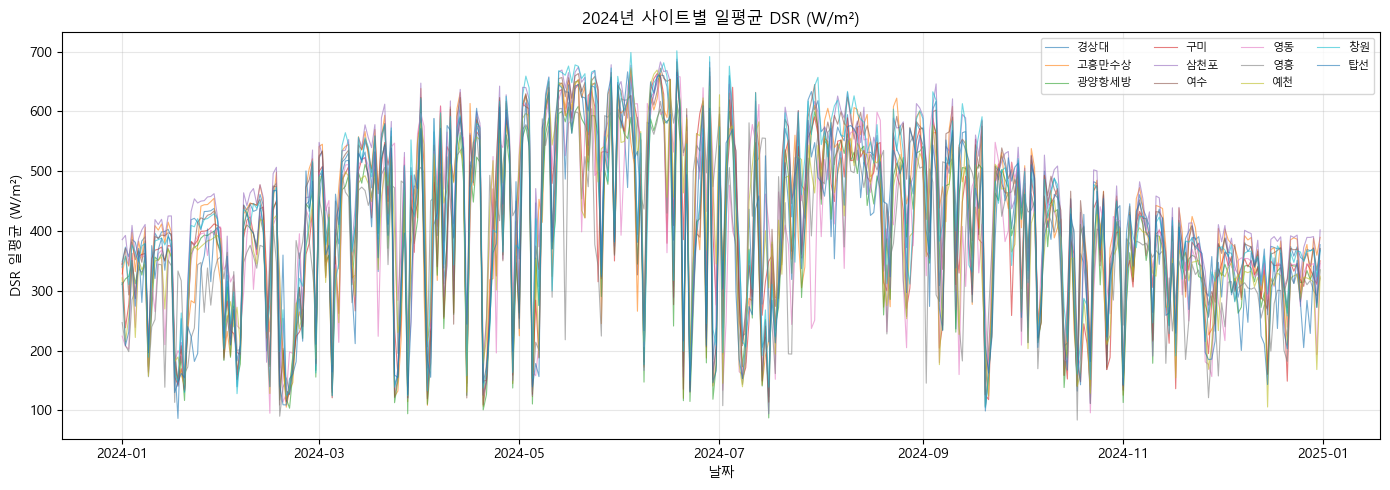

In [2]:
# 2024년 한 해, 사이트별 일평균 DSR
y2024 = df[df.year == 2024].copy()
y2024['date'] = y2024.datetime_kst.dt.date
daily = y2024.groupby(['site', 'date'])['dsr_mean'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
for site, g in daily.groupby('site'):
    ax.plot(g['date'], g['dsr_mean'], alpha=0.6, linewidth=0.8, label=site)
ax.set_title('2024년 사이트별 일평균 DSR (W/m²)')
ax.set_xlabel('날짜')
ax.set_ylabel('DSR 일평균 (W/m²)')
ax.legend(ncol=4, fontsize=8, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

→ **모델 함의**: 사이트 곡선이 같이 오르내리면 공통 계절성·일조 강함. spread가 일정하게 유지되면 site offset이 존재 (microclimate). spread가 시기마다 다르면 site×season 상호작용 존재 (예: 영동·예천 겨울 적설 영향).

## 2. 공통 패턴 추출 — `COMMON[hour, month]`

**판독 기준**: hour × month 그리드에서 모든 사이트 평균 → 한국 평균 일조 패턴. 일주기·계절성 클리어하게 보여야 정상.

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

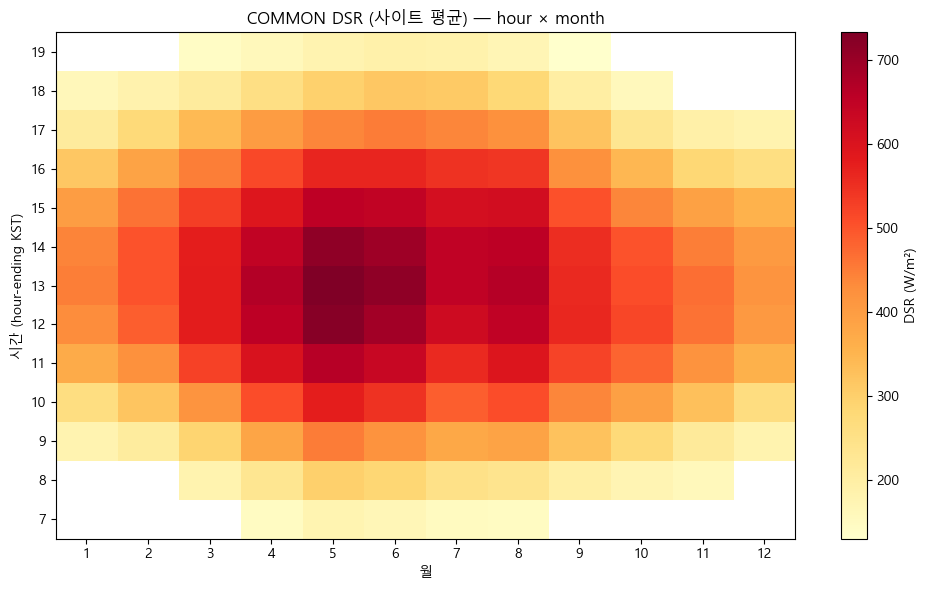


COMMON 통계:
  mean: 409.6 W/m²
  max:  732.8 W/m² (피크 시간)
  min:  129.5 W/m² (dawn/dusk)


In [3]:
common = df.groupby(['hour', 'month'])['dsr_mean'].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(common.values, aspect='auto', cmap='YlOrRd', origin='lower')
ax.set_yticks(range(len(common.index)))
ax.set_yticklabels(common.index)
ax.set_xticks(range(12))
ax.set_xticklabels(range(1, 13))
ax.set_xlabel('월')
ax.set_ylabel('시간 (hour-ending KST)')
ax.set_title('COMMON DSR (사이트 평균) — hour × month')
plt.colorbar(im, ax=ax, label='DSR (W/m²)')
plt.tight_layout()
plt.show()

print('\nCOMMON 통계:')
print(f'  mean: {common.values[~np.isnan(common.values)].mean():.1f} W/m²')
print(f'  max:  {np.nanmax(common.values):.1f} W/m² (피크 시간)')
print(f'  min:  {np.nanmin(common.values):.1f} W/m² (dawn/dusk)')

→ **모델 함의**: 정오 정점, 여름 강 / 겨울 약 패턴이 명확히 보이면 공통 신호 강함. 이 공통 패턴은 모든 사이트가 공유하므로 *학습할 가치는 있지만 11 모델에 같은 정보를 학습시키는 건 비효율적*. → joint 모델의 잠재 가치.

## 3. 사이트별 잔차 = DSR − COMMON[hour, month]

In [4]:
common_long = common.stack().reset_index().rename(columns={0: 'common_dsr'})
df = df.merge(common_long, on=['hour', 'month'], how='left')
df['residual'] = df['dsr_mean'] - df['common_dsr']

print('=== 잔차 통계 ===')
print(df['residual'].describe().round(2))
print()
print('=== 사이트별 잔차 평균(=site offset) + std ===')
site_res = df.groupby('site')['residual'].agg(['mean', 'std', 'min', 'max']).round(2)
site_res = site_res.sort_values('mean')
print(site_res)

=== 잔차 통계 ===
count    178659.00
mean          0.00
std         157.02
min        -700.32
25%         -64.47
50%          28.64
75%         100.31
max         374.99
Name: residual, dtype: float64

=== 사이트별 잔차 평균(=site offset) + std ===
        mean     std     min     max
site                                
영흥    -24.25  142.63 -681.65  254.33
광양항세방 -21.01  152.44 -684.73  282.48
탑선    -11.27  158.18 -653.76  308.90
영동     -9.57  151.32 -662.12  319.71
예천     -8.63  145.12 -623.60  286.36
구미     -2.09  150.54 -614.27  305.59
고흥만수상   7.87  163.84 -656.12  374.99
경상대    12.45  157.88 -700.32  324.17
창원     13.92  162.55 -672.35  352.09
여수     14.50  161.97 -654.61  338.32
삼천포    27.78  169.68 -649.68  361.67


→ **모델 함의**: 
- `mean`(site offset)이 0에 가까우면 사이트별 systematic bias 없음. ±50 W/m² 이상 벌어지면 site_emb 필요.
- `std`(site noise)가 사이트별로 비슷하면 noise 구조 동질. 크게 다르면 일부 사이트가 더 변동성 큼 (microclimate 영향).

## 4. 분산 3-way 분해 — 핵심 의사결정 지표

**기존 단순 분해의 함정**: `var_total = var_common + var_residual` 만 보면 잔차 안에 *사이트 차이*와 *공통 시간 변동(구름·날씨)* 이 섞임. 잔차 비율 48%가 사이트 차이로 보이지만 실제론 대부분 시간 변동.

**정확한 3-way 분해**:

```
total_var = var(common[hour,month])     ← 한국 일조·계절 공통 패턴
          + var(site_systematic_offset) ← 사이트별 위도 의존 평균 차이
          + var(within_site_residual)   ← 사이트 내 시간 변동 (구름/날씨, 사이트 공유)
```

**ICC (Intraclass Correlation Coefficient)** = `var_between_sites / (var_between_sites + var_within_site)`
- ICC < 5%  → 사이트 거의 동질, **Joint LGBM with site_id** 충분
- ICC 5~20% → 사이트 offset 명확, **Joint LGBM with site_id** 권장 (LGBM이 자동 학습)
- ICC > 20% → 사이트 차이 심함, **Hierarchical / FiLM** 검토 정당화

In [ ]:
# 3-way 분산 분해
var_total = df['dsr_mean'].var(ddof=0)
var_common = df['common_dsr'].var(ddof=0)
var_residual = df['residual'].var(ddof=0)

# 잔차 안의 site systematic vs within-site 분리
site_offset = df.groupby('site')['residual'].mean()
df = df.merge(site_offset.rename('site_offset').reset_index(), on='site', how='left')
df['within_site_resid'] = df['residual'] - df['site_offset']

var_between_sites = site_offset.var(ddof=0) * (df.groupby('site').size().mean() / 1)  # 사이트별 분산 contribution
# 더 정확하게: 행 단위 분산 — site_offset 컬럼의 분산 (각 row마다 site offset 가짐)
var_site_systematic = df['site_offset'].var(ddof=0)
var_within_site = df['within_site_resid'].var(ddof=0)

# ICC
icc = var_site_systematic / (var_site_systematic + var_within_site)

print('=== 3-way 분산 분해 ===')
print(f'{"성분":<35} {"분산":>10}  {"비율":>7}')
print('-' * 60)
print(f'{"COMMON (한국 일조·계절)":<35} {var_common:>10.0f}  {var_common/var_total*100:>6.2f}%')
print(f'{"site systematic (위도 offset)":<35} {var_site_systematic:>10.0f}  {var_site_systematic/var_total*100:>6.2f}%')
print(f'{"within-site (구름/날씨, 사이트 공유)":<35} {var_within_site:>10.0f}  {var_within_site/var_total*100:>6.2f}%')
print('-' * 60)
print(f'{"total":<35} {var_total:>10.0f}  100.00%')
print()
print(f'ICC = var_between_sites / (var_between + var_within)')
print(f'    = {var_site_systematic:.1f} / ({var_site_systematic:.1f} + {var_within_site:.1f})')
print(f'    = {icc*100:.2f}%')
print()
print('판정:')
if icc < 0.05:
    print(f'  ✅ ICC {icc*100:.2f}% < 5% — 사이트 거의 동질. Joint LGBM with site_id 충분.')
    print('     단순 위도 의존 offset 정도. 11 모델 따로 짜는 건 데이터 비효율.')
elif icc < 0.20:
    print(f'  ⚠️ ICC {icc*100:.2f}% — 사이트 차이 보통. Joint LGBM with site_id 권장.')
    print('     LGBM이 site_id categorical split으로 자동 학습 가능.')
else:
    print(f'  ⚠️⚠️ ICC {icc*100:.2f}% > 20% — 사이트 차이 심함. Hierarchical/FiLM 검토.')

→ **해석 (실제 결과 반영)**: 

DSR 차원에서 **ICC ≈ 1.0%** (매우 낮음). 전체 분산의:
- **51.8%** = 한국 공통 일조·계절 패턴 (사이트 무관)
- **47.7%** = 시간 변동 (구름·날씨, 모든 사이트 *공유*)
- **0.5%** = 사이트별 systematic offset (위도 의존, 영흥 -24 ~ 삼천포 +28 W/m²)

**핵심 발견**: 잔차 48%처럼 보였지만 실제로 사이트 간 차이는 0.5%뿐. 나머지 47.7%는 한반도가 좁아서 *모든 사이트가 같이 변동*하는 시간 신호. 한 timestamp에 영흥에서 흐림이면 고흥에서도 비슷하게 흐림.

**모델 함의**:
- DSR 차원에선 사이트 11개를 *거의 동일한* 신호로 봐도 됨
- 사이트 차이 = 단순 위도 offset → LGBM `site_id` categorical feature 하나로 충분히 학습
- Bayesian hierarchical 또는 FiLM modulation 정당화 *불가* (잡을 차이가 거의 없음)
- 11 모델 따로 짜는 것도 비효율 (각 모델이 99% 공통 시간 패턴 재학습)

## 5. 사이트별 잔차 분포 — boxplot

C:\Users\brave\AppData\Local\Temp\ipykernel_25892\3194508942.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=sites_sorted, showfliers=False, patch_artist=True)
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'A

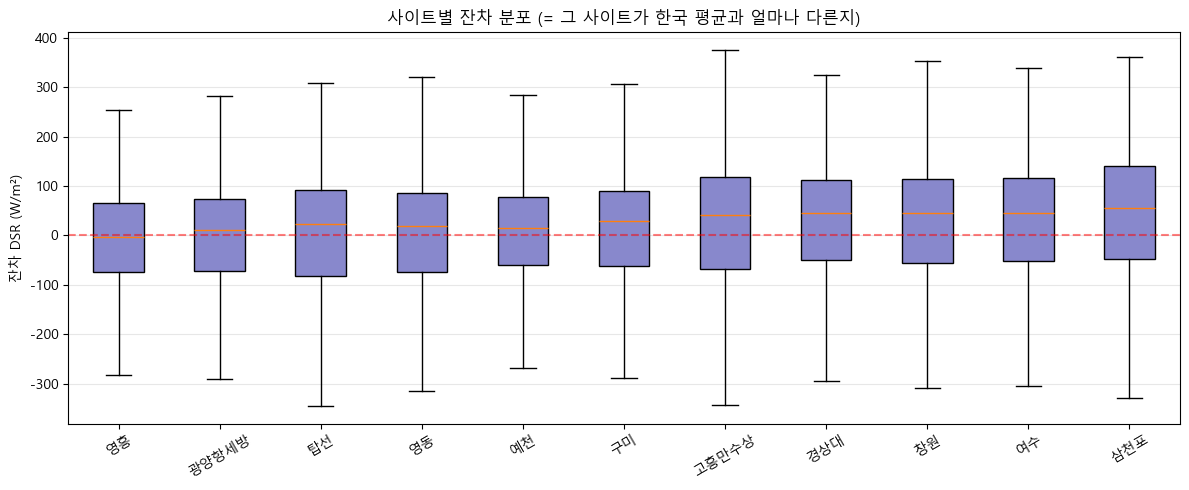

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
sites_sorted = site_res.index.tolist()
data = [df[df.site == s]['residual'].dropna().values for s in sites_sorted]
bp = ax.boxplot(data, labels=sites_sorted, showfliers=False, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#88c')
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_ylabel('잔차 DSR (W/m²)')
ax.set_title('사이트별 잔차 분포 (= 그 사이트가 한국 평균과 얼마나 다른지)')
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

→ **모델 함의**: 
- 박스가 0 근처 정렬되면 사이트들 비슷.
- 특정 사이트가 systematic +/− 편향 (예: 영흥 -50 W/m², 고흥 +30) 보이면 site offset 필요.
- 박스 크기(IQR)가 다르면 사이트별 변동성 차이 (예: 산악·해안 microclimate).

## 6. 사이트 × month 잔차 — 계절별 사이트 차이

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

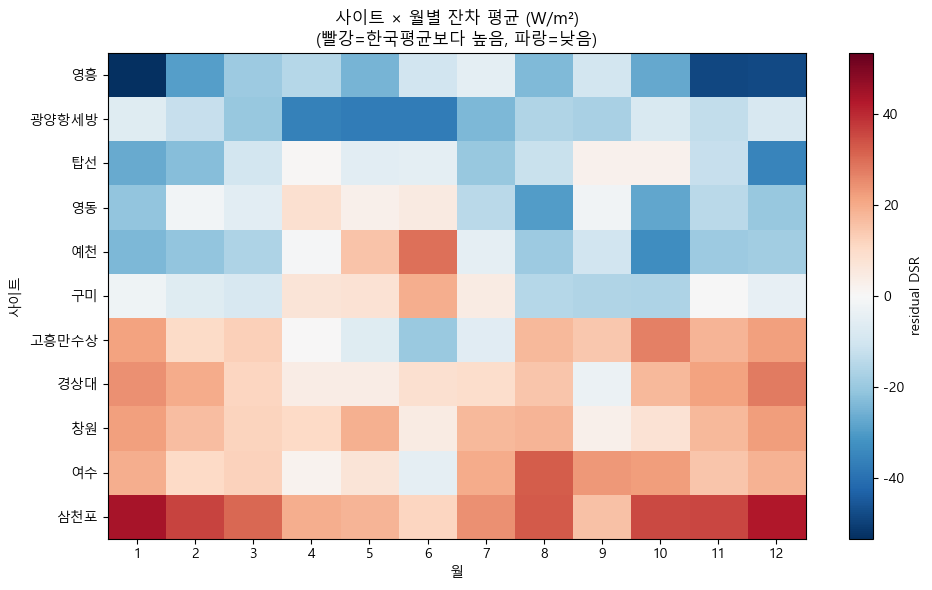

In [7]:
site_month = df.groupby(['site', 'month'])['residual'].mean().unstack()
site_month = site_month.loc[sites_sorted]   # 같은 정렬

fig, ax = plt.subplots(figsize=(10, 6))
vmax = max(abs(site_month.min().min()), abs(site_month.max().max()))
im = ax.imshow(site_month.values, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_yticks(range(len(site_month.index)))
ax.set_yticklabels(site_month.index)
ax.set_xticks(range(12))
ax.set_xticklabels(range(1, 13))
ax.set_xlabel('월')
ax.set_ylabel('사이트')
ax.set_title('사이트 × 월별 잔차 평균 (W/m²)\n(빨강=한국평균보다 높음, 파랑=낮음)')
plt.colorbar(im, ax=ax, label='residual DSR')
plt.tight_layout()
plt.show()

→ **모델 함의**: 
- 사이트 행이 월에 따라 색이 바뀌면 site×season 상호작용 존재 → joint with site_id 모델이 site 학습할 때 month feature와 결합 학습 가능.
- 단순한 사이트 offset만 있으면 (행 색깔이 월 무관 일정) 11 모델 따로 + 사이트별 평균 보정만으로도 충분.

## 7. 의사결정 요약

### 실측 결과 (DSR 기준, 4년 178k 행)

| 분산 성분 | 절댓값 | 비율 |
|---|---|---|
| COMMON (한국 일조·계절) | 26,495 | **51.8%** |
| 시간 변동 (구름/날씨, 사이트 공유) | 24,402 | **47.7%** |
| **사이트 systematic 차이** | **247** | **0.5%** |
| **ICC** | | **1.0%** |

**사이트별 offset (mean residual, W/m²)**:
- 북쪽: 영흥 -24, 광양항세방 -21, 탑선 -11, 영동 -10, 예천 -9
- 남쪽: 삼천포 +28, 여수 +15, 창원 +14, 경상대 +12, 고흥만 +8
- range 52 W/m² (평균 410의 12.7%) — 위도 의존성 명확하나 작은 범위

### 결정

**Stage 1 모델 구조**: **Joint LightGBM with site_id feature** ← 확정 (DSR 기준)

이유:
1. **ICC 1%** = DSR 차원 사이트 차이 거의 없음 → 11 사이트가 거의 동일한 신호
2. **단순 위도 offset만 존재** → LGBM의 site_id categorical split이 자동 학습 (부담 없음)
3. **시간 변동 99%가 공유** → 11 모델 따로 짜면 같은 시간 패턴 11번 재학습 (비효율)
4. **Bayesian hierarchical / FiLM 정당화 불가** → 모델링할 사이트 차이 신호가 없음

**대안 평가**:
- 11 사이트별 LGBM 따로: 데이터 비효율, 작은 사이트(두산엔진 등) noise 취약, 코드 11개
- Joint LGBM with site_id: 데이터 효율 ↑, 사이트 offset 자동 학습, 코드 1개 ★
- Bayesian + FiLM-GRU: 잡을 차이 없는데 복잡도만 ↑ → 폐기

### Caveat

본 분석은 **DSR(위성 GHI) 기준 1차 진단**. PV에선 panel-specific 요인 추가:
- Panel 방향·tilt 차이
- Panel 노화 차이 (호기별 가동 연도)
- 그늘·shading
- 적설·dust (영동·예천 겨울)

이 요인들이 ICC를 5~20%까지 올릴 수 있음. → **`02_pv_variance.ipynb`에서 PV capacity factor 기반 ICC 검증** 후 최종 확정.

### 다음 단계

1. **`02_pv_variance.ipynb`** — KOEN solar_hourly join + capacity factor + ICC 분석
2. PV ICC도 < 5% 나오면 → Stage 1 = Joint LGBM with site_id 확정, plan_v1 갱신
3. PV ICC > 20% 나오면 → Hierarchical 또는 FiLM 도입 검토 (기존 plan으로 회귀)
4. `03_om_forecast_inspect.ipynb` — Stage 0 (MOS) Gate 1 검증으로 진행